# 01 - Models and Data

## Imports

In [198]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515) # note this can be any number 

## What is a Model?

Mathematically, a model is a mapping of one or more inputs to a single output. Therefore it is a function! 

We have some pretty basic functions that you've seen before, like the basic function for a line: 

$y = mx + b$

Let's look at what makes this a model/function: 

In [202]:
# sample slope function 

def slope(m, x, b):
    ''' Calculate the y variable for the linear model
    '''
    return m*x + b

m = 2
x = 3
b = 0

test_slope = slope(m, x, b)
print(test_slope)

6


What makes our slope function a model is that we can take some basic inputs ($b$, $x$) and map them to the output ($y$) via a transformation ($m$). Ultimately, ML is about finding models that can give us **useful** outputs for our tasks. 

## Data Dictates the Model

In the previous file, we talked about how ML is specifically about learning patterns from data and finding functions/models that show us those patterns. So, inherently, the quality of our data is the **most important** part of being successful at building models to help us with our task. 

But what does good data actually look like?

### Good Data: Studying and Exam Scores

Let's say you're interested in understanding the relationship between hours of studying and the test scores for AP Calculus AB. 

Suppose you come across this plot about the relationship between studying for a math test and getting good grades in the Period 3 AP Calculus AB class. 

Note that I am showing you the generation code for the plot so you can see what this looks like, but of course in real life you would have no idea what this looks like! 

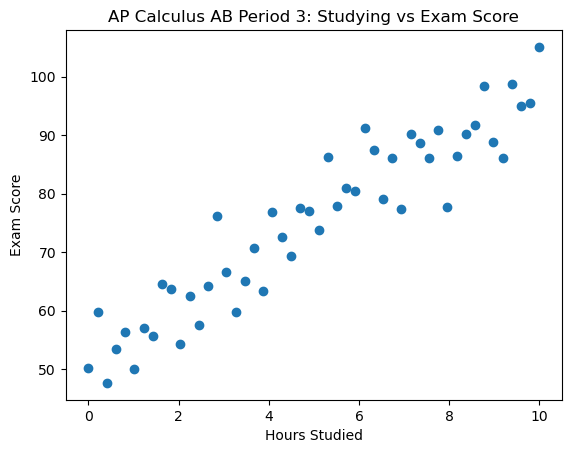

In [209]:
# Hours studied
hours = np.linspace(0, 10, 50)

# Exam score with moderate noise
scores_good = 5 * hours + 50 + np.random.normal(0, 5, size=len(hours))

plt.figure()
plt.scatter(hours, scores_good)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score")
plt.show()

In the code generation, you may have noticed that we had the typical formula for creating a line $y=mx+b$, but we also added some random noise. You can think of noise to be anything that blocks the true relationship we are interested in: measurement error, missing data (or biased data!), etc. 

So, if we remove that noise, we get the relationship we are interested in measuring, in this case the relationship between hours studied and the exam scores in AP Calculus *as a whole* (not just period 3):

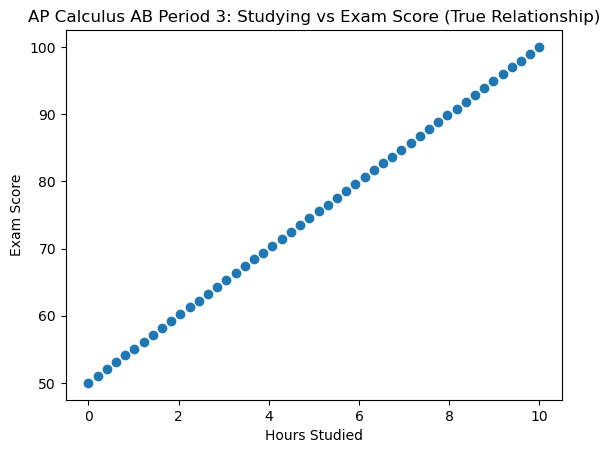

In [212]:
# True relationship 
scores_perfect = 5 * hours + 50

plt.figure()
plt.scatter(hours, scores_perfect)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score (True Relationship)")
plt.show()

It is a perfectly linear relationship! But, in real life, we never actually observe the true underlying relationship we are interested in finding. Instead, we get data that looks like the first plot - some noise, that could've come from things like measurement error, human error, missing data, etc.

Let's we go back to that first plot: 

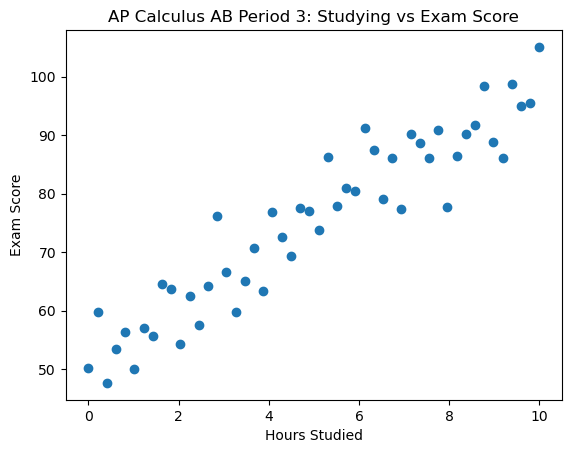

In [216]:
plt.figure()
plt.scatter(hours, scores_good)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score")
plt.show()

If you were to guess the relationship between the hours studied and exam score, you would still probably guess something that looks like the below code. Note that I am using a function to find a fitting line (don't worry about how that calculation is done), but I think you will see that visually it matches up to what you would guess. 

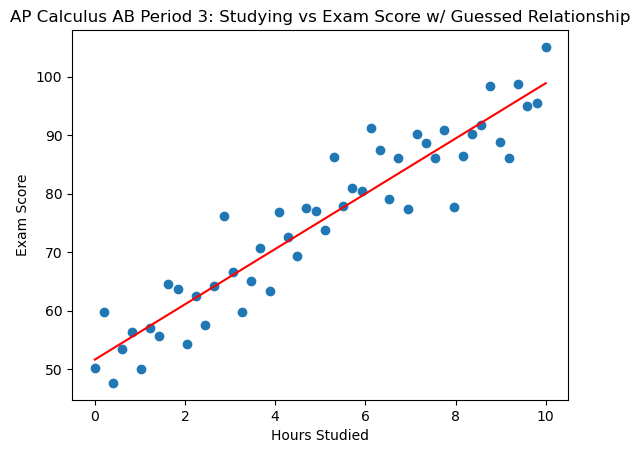

In [219]:
slope_good, intercept_good = np.polyfit(hours, scores_good, deg=1) # fit a polynomial to your data 
y_fit_good = slope_good * hours + intercept_good


plt.figure()
plt.scatter(hours, scores_good)
plt.plot(hours, y_fit_good, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score w/ Guessed Relationship")
plt.show()

Now, think about why you were able to guess a line would fit the data well.  

It is because the data that you were given wasn't that noisy, so you could reasonably guess what the relationship was. 

But what if our data was much noisier? 

### Bad Data: Studying and Exam Scores

Suppose instead of coming across the previous data about AP Calculus AB Period 3, you came across this other plot that another student gave you.

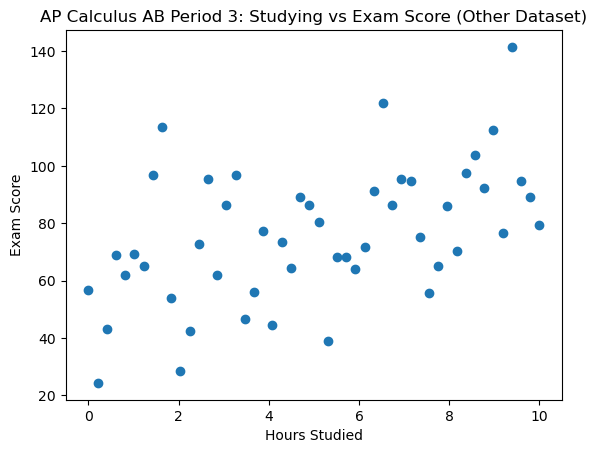

In [224]:
# Exam score with heavy noise



scores_bad = 5 * hours + 50 + np.random.normal(0, 20, size=len(hours))

plt.figure()
plt.scatter(hours, scores_bad)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score (Other Dataset)")
plt.show()

If I then asked you to guess the relationship, would you still guess a line? Probably not, but let's see what a line would look like using that same function we used above:

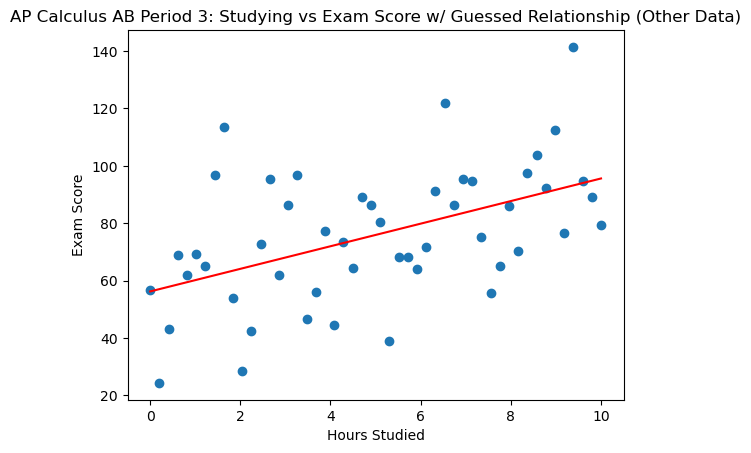

In [227]:
slope_bad, intercept_bad = np.polyfit(hours, scores_bad, deg=1)
y_fit_bad = slope_bad * hours + intercept_bad

plt.figure()
plt.scatter(hours, scores_bad)
plt.plot(hours, y_fit_bad, color = 'red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("AP Calculus AB Period 3: Studying vs Exam Score w/ Guessed Relationship (Other Data)")
plt.show()

Notice that this line doesn't fit our data as well, and looks fundamentally different from the line we guessed before (and the true relationship we saw earlier).

So, you've seen an example as to how problematic having bad data can be for our model. We get a wrong relationship - but what does this mean for our model? 

If we have control over the data we can capture, we **must** make sure we do a good job of getting data that doesn't hide the relationships we are trying to find. As we will cover in the next notebook, good data is key to the most important part of our model - its performance on data it has never seen before.